# The onset temperature of the Er$^{3+}$ Boltzmann thermometer depends on excitation power

**Claim.** In $\beta$-NaYF$_4$:18Yb,2Er, the green LIR $I(^2H_{11/2})/I(^4S_{3/2})$ leaves the Boltzmann law below a kinetic onset temperature $T_{on}$ (Suta 2025). The rate-equation model `AndersonModelUnfoldedAssitedETU` predicts that $T_{on}$ is not a material constant but rises with the 980 nm power density. The model is built only from independently sourced parameters: Anderson 2013 at 300 K, Suta 2025, Suyver 2006, and Yu 2014 for $\eta$.

The cause is energy-transfer upconversion out of $^4S_{3/2}$ ($^4S_{3/2} + {}^2F_{5/2} \to {}^4G_{11/2} + {}^2F_{7/2}$, Anderson's $k_{ET6-9}$). It adds a pump-dependent term to the $^4S_{3/2}$ decay rate $k_1$, which sets $T_{on}$. The effect survives even though this transfer is phonon-assisted and freezes out on cooling. Yu's green emission, which rises on cooling, independently requires that freeze-out.

Central prediction ($\hbar\omega$ = 298 cm$^{-1}$, $T_{on}$ = 103 K at 5.5 mW/cm$^2$), with the full sensitivity band in brackets:
- $\Delta T_{on}$ = +7.8 K at 100 W/cm$^2$ [+6.9, +16.4]
- $\Delta T_{on}$ = +12.1 K at 300 W/cm$^2$ [+10.9, +23.3]
- $\Delta T_{on}$ = +18.8 K at 1 kW/cm$^2$ [+17.1, +33.1]

These shifts compare with Suta's ±5 K. Directly measurable signature: at 100 K, the initial decay rate of $^4S_{3/2}$ under a CW 980 nm pump rises from 3.2 to 8.1 ms$^{-1}$ at 300 W/cm$^2$.

Structure: (1) model, parameter sources, calibration vs held-out data; (2) the result with its sensitivity band, and the thermometry bias; (3) held-out comparisons; (4) mechanism, an exact two-level reduction; (5) proposed experiment; (6) draft for the paper.

In [1]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from pint import get_application_registry
from poincare import solvers
from scipy.optimize import brentq, curve_fit

from upconversion_models import AndersonModel, AndersonModelUnfoldedAssitedETU as M, cmap
from upconversion_models.jablonski_patch import (
    EmissionTransform,
    PulsedExcitation,
    Simulator,
    SteadyState,
)

warnings.filterwarnings("ignore")
u = get_application_registry()
pd.set_option("display.width", 160)

hc_k = 1.4388  # cm K, hc / k_B
gap = 650.0  # cm-1, Er6h - Er6s (Suta 2025)
g_s, g_h = 4, 12
C = (M.k_r6h.default / M.k_r6s.default).to("").magnitude  # k_r6h / k_r6s = 5.52 / 3
knr0 = M.k_therm.default.to("1/s").magnitude
photon_energy = (6.62607015e-34 * 2.99792458e8 / 980e-9)  # J

solver = solvers.LSODA(rtol=1e-10, atol=1e-18)
sim = Simulator(M()).with_transform(EmissionTransform("emission"), append=True).with_solver(solver)
anderson = (
    Simulator(AndersonModel()).with_transform(EmissionTransform("emission"), append=True).with_solver(solver)
)
steady = SteadyState()


def value(ds, key):
    v = ds[key].item()
    return getattr(v, "magnitude", v)


def W(P):
    return P * u.W / u.cm**2

## 1. Model, parameter sources and data split

`AndersonModelUnfoldedAssitedETU` is Anderson's model with level 6 split into $^4S_{3/2}$ (Er6s, 18300 cm$^{-1}$) and $^2H_{11/2}$ (Er6h, 18950 cm$^{-1}$). Every temperature-dependent rate is anchored at $T_0 = 300$ K to Anderson's value:

- **Multiphonon relaxation** $i \to j$ (energy-gap law, $p = \Delta E_{ij}/\hbar\omega$, $n = 1/(e^{\hbar\omega/kT}-1)$), with its detailed-balance partner:
$$k_{i\to j}(T) = k_{i\to j}(T_0)\left[\frac{1+n(T)}{1+n(T_0)}\right]^p, \qquad \frac{k_{j\to i}}{k_{i\to j}} = \frac{g_i}{g_j}e^{-\Delta E_{ij}/kT}$$
- **Phonon-assisted energy transfer**: a mismatch $\Delta E$ emitted as phonons gives $k(T) = k(T_0)\,F_{\Delta E}(T)$, with $F_{\Delta}(T) = [(1+n(T))/(1+n(T_0))]^{\Delta/\hbar\omega}$. For 6s→9 the barycenter mismatch is $18300 + 10200 - 26100 = 2400$ cm$^{-1}$; for 6h→9 it is 3050 cm$^{-1}$.
- **Yb$^{3+}$ crystal-field weighting** of the resonant Yb→Er $^4I_{11/2}$ steps: $k \propto \eta + (1-\eta)\,p_1(T)$, with $p_1 = 1/(1+e^{\Delta_{01}/kT})$.
- **$^2H_{11/2} \leftrightarrow {}^4S_{3/2}$ coupling** (Suta 2025, eq. 6): $k_{21} = g_s k_{nr}(0)(1+n)^p$ and $k_{12} = g_h k_{nr}(0)n^p$, with $p = 650/\hbar\omega$.

**Checks done before this notebook.**
- *Reduction to Anderson at $T_0$.* With the 6s and 6h lines recombined, the model reproduces `AndersonModel` within 0.2 % (green, red, blue at 1, 5 and 50 W/cm$^2$). The 1–2 % red/blue offset of `AndersonModelUnfolded` comes entirely from the detailed-balance partner of $k_{nr9}$. The 8→9 thermal excitation (gap 1600 cm$^{-1}$) runs at ~980 s$^{-1}$ at 300 K, 2.1 % of the $^2H_{9/2}$ decay. Switching it off (`detailed_balance = 0`) restores red and blue to 0.1 %, and switching off every partner restores all lines to 0.1 %. The partner is physical, so it is kept. Anderson's $k_{ET9-5}$ is rescaled by 0.977, well inside his ±28 %, to absorb the extra $^4G_{11/2}$ population. This is calibration against Anderson at $T_0$, not against any held-out observable.
- *Yu 2014 (calibration set).* With $\eta = 0.1$ (calibrated in `claude/paper2.ipynb`), the ported model still follows Yu's relative 541 nm, blue and $R_{r/g}$ curves at 290 W/cm$^2$, with rms log10 deviations of 0.135, 0.205 and 0.159. No recalibration was needed.

Every parameter is traced in the table below.

In [2]:
hw0 = M.phonon_wavenumber.default.to("1/cm").magnitude
sources = pd.DataFrame(
    [
        ("Level barycenters Er1..Er9, Yb2", "0 ... 26100, 10200 cm-1", "Anderson 2013 (Fig 1)", "calibration"),
        ("Er6h - Er6s", f"{gap:.0f} cm-1", "Suta 2025, 77 K excitation spectra", "calibration"),
        ("k_r6h / k_r6s", f"{C:.3f} (= 5.52 / 3)", "Suta 2025, LIR fit C g2/g1 = 5.52", "calibration"),
        ("k_r6s, k_r6h", f"{M.k_r6s.default:~P}, {M.k_r6h.default:~P}", "split of Anderson k_r6 = 1510 1/s at T0", "derived"),
        ("k_therm = knr(0)", f"{knr0:.3g} 1/s", "Suta 2025 (assumes p = 2, hw_eff = 325 cm-1)", "calibration"),
        ("6h<->6s rates", "4 knr0 (1+n)^p down, 12 knr0 n^p up", "Suta 2025 eq. 6 convention", "calibration"),
        ("phonon_wavenumber", f"{hw0:.0f} cm-1 (band 298-370)", "Suyver 2006, Raman modes 298 / 370 / 418", "calibration"),
        ("Yb |0>-|1> gap", "38 cm-1", "Suyver 2006", "calibration"),
        ("yb_ground_efficiency eta", f"{M.yb_ground_efficiency.default}", "Yu 2014 Fig 4a,4b,5d,7 (claude/paper2.ipynb)", "calibration"),
        ("resonant_fraction r", "0", "model choice (only endothermic: cross4, etu52 = 0)", "assumption"),
        ("all k_ET, k_nr, k_r, k_cr, k_uc2 at T0", "Table 1", "Anderson 2013 (300 K, beta-NaYF4:18Yb,2Er powder)", "calibration"),
        ("k_95", f"{M.k_95.default:~P}", "Anderson 2.84e-16 x 0.977 (T0 reduction, see Validation)", "calibration"),
        ("CR6 split k_cr6s / k_cr6", "1 (equal) or 0.614 (Suta-fixed)", "Anderson constraint at T0; Suta tau(77 K) for the 2nd", "uncertainty band"),
        ("6s->9 / 6h->9 mismatch", "2400 / 3050 cm-1 emitted", "barycenters (resonant bound: 0)", "uncertainty band"),
        ("g = 2J + 1", "14, 12, 10, 10, 4, 12, 8, 10, 12", "levels 2..9", "fixed"),
        ("isolated fraction beta", f"{M.isolated_percentage.default}", "Anderson 2013", "calibration"),
        ("site density", f"{M.site_density.default:~P}", "beta-NaYF4 cation sites", "fixed"),
        ("yb_cross_section", f"{M.yb_cross_section.default:~P}", "placeholder; literature ~1.2e-20 cm2 at 980 nm", "power axis +-20 %"),
    ],
    columns=["parameter", "value", "source", "role"],
).set_index("parameter")
sources

,value,source,role
parameter,,,
"Level barycenters Er1..Er9, Yb2","0 ... 26100, 10200 cm-1",Anderson 2013 (Fig 1),calibration
Er6h - Er6s,650 cm-1,"Suta 2025, 77 K excitation spectra",calibration
k_r6h / k_r6s,1.839 (= 5.52 / 3),"Suta 2025, LIR fit C g2/g1 = 5.52",calibration
"k_r6s, k_r6h","1375 1/s, 2529 1/s",split of Anderson k_r6 = 1510 1/s at T0,derived
k_therm = knr(0),2.29e+06 1/s,"Suta 2025 (assumes p = 2, hw_eff = 325 cm-1)",calibration
6h<->6s rates,"4 knr0 (1+n)^p down, 12 knr0 n^p up",Suta 2025 eq. 6 convention,calibration
phonon_wavenumber,298 cm-1 (band 298-370),"Suyver 2006, Raman modes 298 / 370 / 418",calibration
Yb |0>-|1> gap,38 cm-1,Suyver 2006,calibration
yb_ground_efficiency eta,0.1,"Yu 2014 Fig 4a,4b,5d,7 (claude/paper2.ipynb)",calibration


### Calibration vs held-out data

This separation is kept strictly throughout the notebook.

**Calibration** (parameters may come from these):
- Anderson 2013: every rate at 300 K (Table 1, $\beta$-NaYF$_4$:18Yb,2Er micrometer powder).
- Suta 2025: $\Delta E = 650$ cm$^{-1}$, $C g_2/g_1 = 5.52$, $k_{nr}(0) = 2.29\ \mu s^{-1}$ (obtained by Suta with $p = 2$, $\hbar\omega_{eff}$ = 325 cm$^{-1}$).
- Suyver 2006: $\hbar\omega$ (Raman modes, 298–370 cm$^{-1}$) and $\Delta_{01} = 38$ cm$^{-1}$.
- Yu 2014: only what `claude/paper2.ipynb` used for $\eta$ (Fig 4a, 4b, 5d, 7). In section 2 the same data also choose between the bounds of the 6s→9 mismatch, which is a calibration choice as well.
- CR6 split: free under $f_s(T_0)k_{cr6s} + f_h(T_0)k_{cr6h} = k_{cr6}$. It is carried as an uncertainty band: equal split, or Suta-fixed ($k_{cr6s}$ set by Suta's $\langle\tau\rangle$(77 K)). In the Suta-fixed branch, $\langle\tau\rangle$(77 K) is calibration and not a test.

**Held out** (tests only, never tuned):
- Suta 2025: $\langle\tau\rangle$(77 K) = 0.41 ms (a test for the equal split only), $k_r(^4S_{3/2})$ = 1.55 ms$^{-1}$, and $T_{on}$ = 100 ± 5 K at ~5.5 mW/cm$^2$. Caveat: Suta obtained $k_{nr}(0)$ from $T_{on}$ and $k_1$ through eq. 6, so reproducing $T_{on}$ at Suta's power is a consistency check, not an independent test.
- Xu 2024 ($\beta$-NaYF$_4$:20Yb,2Er hydrothermal microrods): 980 nm-excited decays (Fig 5), power-law slopes at 303 and 483 K (Fig 3), FIR(520/541) over 353–453 K.
- Yu 2014 Fig 5c ($R_{HS}$), which was not used for $\eta$.

**The observable of the result, $T_{on}$ versus excitation power, appears in no source.**

In [3]:
# Suta 2025 (held out, except <tau>(77 K) in the Suta-fixed CR6 split)
suta_k1, suta_Ton, suta_Ton_err, suta_P, suta_kr = 2430.0, 100.0, 5.0, 5.5e-3, 1550.0

def k1_direct(s, T, t_end=5e-3, n=20001):
    """Pump-free 4S3/2 decay rate after direct excitation of 2H11/2 (Suta's 515 nm experiment):
    inverse of the intensity-weighted average decay time of line_rad6s1."""
    t = np.linspace(0, t_end, n)
    ds = s.with_values({M.T: T * u.K, M.Er6h: 1e-8}).solve(save_at=t * u.s).pint.dequantify()
    I = ds["line_rad6s1"].values
    return np.trapezoid(I, t) / np.trapezoid(t * I, t)


fs0 = 1 / (1 + 3 * np.exp(-gap * hc_k / 300))
k_cr6 = M.k_cr6.default.to("cm**3/s").magnitude


def cr6_split(x):
    """k_cr6s = x k_cr6 and k_cr6h from Anderson's constraint at T0."""
    return {
        M.k_cr6s: x * k_cr6 * u.cm**3 / u.s,
        M.k_cr6h: (1 - fs0 * x) / (1 - fs0) * k_cr6 * u.cm**3 / u.s,
    }


def boltzmann(T):
    return C * g_h / g_s * np.exp(-gap * hc_k / T)


def excess(s, P, T):
    ds = steady.solve(s.with_values({M.energy_flux: W(P), M.T: T * u.K}))
    return value(ds, "line_rad6h1") / value(ds, "line_rad6s1") / boltzmann(T) - 1


def onset(s, P, lo=50.0, hi=300.0):
    """T_on: kinetic floor = Boltzmann term, i.e. LIR = 2 x Boltzmann."""
    return brentq(lambda T: np.log(excess(s, P, T)), lo, hi, xtol=0.05)


base = {}  # (hw, split) -> simulator
xs = {}
for hw in [298, 370]:
    s = sim.with_values({M.phonon_wavenumber: hw / u.cm})
    xs[hw] = brentq(lambda x: k1_direct(s.with_values(cr6_split(x)), 77) - suta_k1, 0, 1 / fs0, xtol=1e-5)
    base[(hw, "equal")] = s.with_values(cr6_split(1.0))
    base[(hw, "Suta-fixed")] = s.with_values(cr6_split(xs[hw]))



def mismatch69(m6s):
    # signed mismatch of 6s->9 (6h->9 is 650 cm-1 larger); 0 = resonant
    m6h = m6s + gap if m6s > 0 else 0
    return {M.etu6s9._mismatch_wavenumber: m6s / u.cm, M.etu6h9._mismatch_wavenumber: m6h / u.cm}

## 2. Result: $T_{on}$ rises with excitation power

At Suta's 5.5 mW/cm$^2$, the decay rate $k_1$ of $^4S_{3/2}$ is intrinsic: radiative decay, multiphonon relaxation and phonon-assisted cross relaxation. Under stronger 980 nm pumping, the excited Yb$^{3+}$ population $N_{Yb^*}$ opens the ETU channel to $^4G_{11/2}$, which adds $k_{ET6-9}\,\rho\,N_{Yb^*}(P,T)\,F_{2400}(T)$ to $k_1$. $T_{on}$ increases with $k_1$ (Suta's eq. 6), so it must increase with power.

$T_{on}$ is defined, as in Suta, as the temperature where the kinetic floor of the LIR equals the Boltzmann term, i.e. LIR = 2 × $C(g_h/g_s)e^{-\Delta E/kT}$. It is found by root-finding on $T$ in steady state.

### 2.1 Bounding the 6s→9 mismatch with Yu 2014 (calibration set)

The most uncertain ingredient is the temperature dependence of the 6s→9 transfer.
- At the barycenters, 2400 cm$^{-1}$ must be emitted as phonons: $F_{2400}(110\ \text{K}) \approx 0.12$ at $\hbar\omega$ = 298 cm$^{-1}$.
- If the real target is the dense $^4G_{9/2}/{}^2K_{15/2}/{}^2G_{7/2}$ region near 27300–28000 cm$^{-1}$, the transfer is nearly resonant and does not freeze out.

Yu's relative 541 nm intensity and $R_{r/g}$ discriminate between the two.

In [4]:
yu = pd.DataFrame(
    {
        "blue": [2.8e3, 2.5e3, 2.0e3, 6.7e3, 2.75e3, 1.7e3, 0.85e3, 0.35e3, 0.2e3, 0.1e3],
        "S": [2.9e4, 3.4e4, 3.65e4, 5.3e4, 4.25e4, 2.7e4, 2.4e4, 1.55e4, 1.1e4, 1.05e4],
        "R_HS": [0, 0, 0, 0, 0.02, 0.12, 0.23, 0.30, 0.58, 0.80],
        "R_rg": [0.21, 0.22, 0.22, 0.19, 0.20, 0.20, 0.31, 0.35, 0.68, 1.0],
    },
    index=pd.Index([10, 30, 50, 100, 150, 200, 250, 300, 350, 400], name="T"),
)  # Yu 2014 bulk, as transcribed in claude/paper2.ipynb
Ts_yu = yu.index.to_numpy() * 1.0


cases_69 = {"2400 (barycenter)": 2400, "1800": 1800, "1200": 1200, "700": 700, "0 (resonant)": 0}
yu_model = {}
for name, m in cases_69.items():
    ds = steady.sweep(
        sim.with_values(mismatch69(m) | {M.energy_flux: W(290)}), variable=M.T, values=Ts_yu * u.K
    )
    yu_model[name] = pd.DataFrame(
        {
            "S": ds["line_rad6s1"].values,
            "blue": ds["line_rad81"].values,
            "R_rg": (ds["line_rad51"] / (ds["line_rad6s1"] + ds["line_rad6h1"])).values,
            "R_HS": (ds["line_rad6h1"] / ds["line_rad6s1"]).values,
        },
        index=yu.index,
    )

cols = ["S", "blue", "R_rg"]
rel_yu = yu[cols] / yu.loc[300, cols]
rms_yu = pd.DataFrame(
    {
        name: np.log10((df[cols] / df.loc[300, cols]) / rel_yu).pow(2).mean().pow(0.5)
        for name, df in yu_model.items()
    }
).T.rename(columns=lambda c: f"rms log10 {c}")
rms_yu.index.name = "6s->9 mismatch [cm-1]"
display(rms_yu.round(3))

,rms log10 S,rms log10 blue,rms log10 R_rg
6s->9 mismatch [cm-1],,,
2400 (barycenter),0.135,0.205,0.159
1800,0.199,0.190,0.130
1200,0.321,0.182,0.258
700,0.440,0.180,0.391
0 (resonant),0.619,0.183,0.591


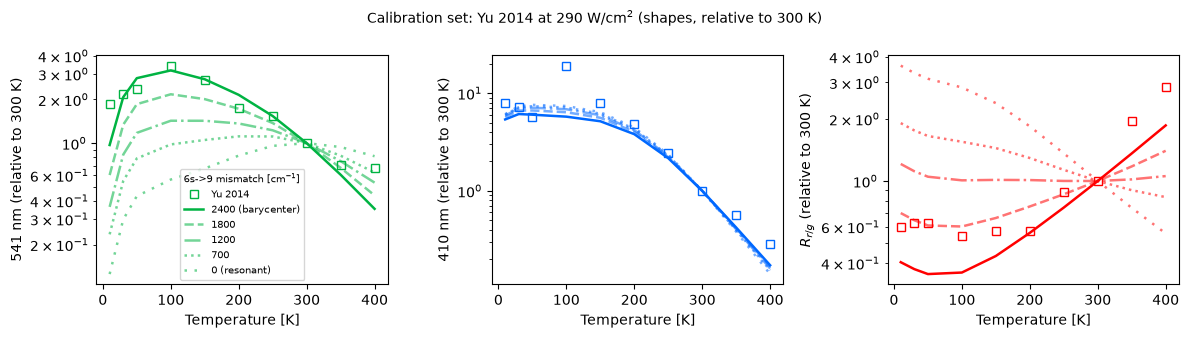

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
styles = dict(zip(cases_69, ["-", "--", "-.", ":", (0, (1, 3))]))
for ax, col, color, label in [
    (axs[0], "S", cmap["g"], "541 nm (relative to 300 K)"),
    (axs[1], "blue", cmap["b"], "410 nm (relative to 300 K)"),
    (axs[2], "R_rg", cmap["r"], r"$R_{r/g}$ (relative to 300 K)"),
]:
    ax.semilogy(yu.index, rel_yu[col], "s", color=color, mfc="none", label="Yu 2014")
    for name, df in yu_model.items():
        ax.semilogy(df.index, df[col] / df.loc[300, col], ls=styles[name], color=color, lw=1.8,
                    alpha=1 if name.startswith("2400") else 0.55, label=name)
    ax.set_ylabel(label)
    ax.set_xlabel("Temperature [K]")
axs[0].legend(fontsize=7, title="6s->9 mismatch [cm$^{-1}$]", title_fontsize=7)
fig.suptitle("Calibration set: Yu 2014 at 290 W/cm$^2$ (shapes, relative to 300 K)", fontsize=10)
fig.tight_layout()
plt.show()

A resonant 6s→9 transfer keeps draining $^4S_{3/2}$ into the red and blue on cooling. The 541 nm emission then *collapses* below 200 K (×0.13 at 10 K, against Yu's ×1.9) and $R_{r/g}$ rises ×3.6 instead of falling. The rms log10 deviation of the green grows monotonically as the mismatch shrinks: 0.135 at 2400 cm$^{-1}$, 0.20 at 1800, 0.32 at 1200, 0.44 at 700 and 0.62 at 0. Yu's data thus require a strongly phonon-assisted 6s→9 transfer, with mismatch ≳ 1800–2400 cm$^{-1}$, consistent with the barycenter value.

The band below therefore uses the barycenter mismatch: the *pessimistic* case for the effect, since any stronger transfer only enlarges it. The resonant case is drawn only as an excluded upper bound.

### 2.2 Sensitivity band

The band covers all combinations of:
- $\hbar\omega$ = 298 or 370 cm$^{-1}$ (Suyver's Raman modes);
- CR6 split: equal, or Suta-fixed (recomputed for each $\hbar\omega$ so that $\langle\tau\rangle$(77 K) = 0.41 ms);
- $k_{ET6-9} = (6.07 \pm 0.85)\times10^{-15}$ cm$^3$/s (Anderson's Table 1; the same value for 6s→9 and 6h→9).

The power axis assumes $\sigma = 10^{-20}$ cm$^2$. With the 1.2×10$^{-20}$ cm$^2$ usually quoted for Yb$^{3+}$ at 980 nm, every power reads 1.2× lower. The top axis gives the Yb$^{3+}$ excitation rate $\sigma\Phi$, which is what the model depends on. In scattering powders, the effective $\sigma\Phi$ may differ from the incident value.

In [6]:
powers = np.array([5.5e-3, 0.1, 1, 10, 30, 100, 300, 1000, 3000])
k69 = M.k_6s9.default.to("cm**3/s").magnitude
dk69 = 0.85e-15


def k69_values(f):
    k = (k69 + f * dk69) * u.cm**3 / u.s
    return {M.k_6s9: k, M.k_6h9: k}


band = {}
for (hw, split), s in base.items():
    for f in [-1, 0, 1]:
        band[(hw, split, f)] = np.array([onset(s.with_values(k69_values(f)), P) for P in powers])
band = pd.DataFrame(band, index=pd.Index(powers, name="P [W/cm2]"))
band.columns.names = ["hw", "split", "k_69 shift [sigma]"]
resonant = np.array([onset(base[(298, "equal")].with_values(mismatch69(0)), P) for P in powers])
dT = band - band.iloc[0]
print("T_on [K]")
display(band.round(1))
print("Delta T_on = T_on(P) - T_on(5.5 mW/cm2) [K]")
display(dT.round(1))
print("resonant 6s->9 (excluded by Yu, upper bound), hw = 298, equal:", np.round(resonant, 1))

T_on [K]


hw                    298                                           370                                       
split               equal               Suta-fixed                equal               Suta-fixed              
k_69 shift [sigma]     -1      0      1         -1      0      1     -1      0      1         -1      0      1
P [W/cm2]                                                                                                     
0.0055              102.9  102.9  102.9      100.1  100.1  100.1  107.8  107.8  107.8      100.2  100.2  100.2
0.1000              102.9  102.9  102.9      100.2  100.2  100.2  107.9  107.9  107.9      100.3  100.3  100.4
1.0000              103.2  103.3  103.4      100.6  100.6  100.7  108.5  108.6  108.7      101.2  101.4  101.5
10.0000             104.9  105.3  105.6      102.5  102.9  103.2  111.3  111.8  112.3      105.2  105.9  106.5
30.0000             106.8  107.3  107.8      104.6  105.2  105.7  114.1  114.9  115.6      108.8  109.7  110.7
100.0000            109.8  110.7  111.5      107.9  108.8  109.7  118.4  119.6  120.7      113.9  115.3  116.6
300.0000            113.8  115.0  116.2      112.2  113.5  114.7  123.7  125.3  126.8      120.0  121.8  123.5
1000.0000           120.0  121.7  123.4      118.8  120.7  122.4  131.4  133.6  135.7      128.8  131.1  133.3
3000.0000           128.9  131.3  133.6      128.2  130.7  133.0  141.6  144.5  147.2      139.8  142.8  145.6

Delta T_on = T_on(P) - T_on(5.5 mW/cm2) [K]


hw                   298                                      370                                   
split              equal             Suta-fixed             equal             Suta-fixed            
k_69 shift [sigma]    -1     0     1         -1     0     1    -1     0     1         -1     0     1
P [W/cm2]                                                                                           
0.0055               0.0   0.0   0.0        0.0   0.0   0.0   0.0   0.0   0.0        0.0   0.0   0.0
0.1000               0.0   0.0   0.1        0.0   0.1   0.1   0.1   0.1   0.1        0.1   0.1   0.2
1.0000               0.4   0.4   0.5        0.4   0.5   0.6   0.6   0.7   0.8        1.0   1.2   1.3
10.0000              2.1   2.4   2.7        2.4   2.7   3.1   3.5   4.0   4.4        5.0   5.7   6.3
30.0000              3.9   4.4   5.0        4.4   5.0   5.6   6.3   7.1   7.8        8.6   9.5  10.5
100.0000             6.9   7.8   8.6        7.8   8.7   9.6  10.6  11.8  12.9       13.7  15.1  16.4
300.0000            10.9  12.1  13.3       12.1  13.4  14.6  15.8  17.4  18.9       19.8  21.6  23.3
1000.0000           17.1  18.8  20.5       18.7  20.5  22.2  23.6  25.8  27.9       28.6  30.9  33.1
3000.0000           26.0  28.4  30.7       28.1  30.6  32.8  33.7  36.7  39.3       39.6  42.6  45.4

resonant 6s->9 (excluded by Yu, upper bound), hw = 298, equal: [102.9 103.3 105.9 115.1 121.8 130.5 140.1 153.  168.6]


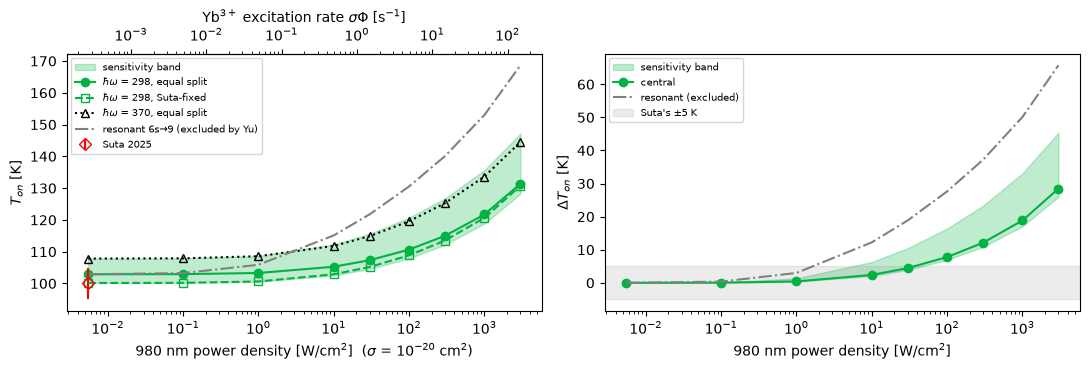

In [7]:
yb_rate = M.yb_cross_section.default.to("cm**2").magnitude * powers / photon_energy  # 1/s per Yb
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axs[0]
ax.fill_between(powers, band.min(axis=1), band.max(axis=1), color=cmap["g"], alpha=0.25, label="sensitivity band")
ax.semilogx(powers, band[(298, "equal", 0)], "o-", color=cmap["g"], label=r"$\hbar\omega$ = 298, equal split")
ax.semilogx(powers, band[(298, "Suta-fixed", 0)], "s--", color=cmap["g"], mfc="none", label=r"$\hbar\omega$ = 298, Suta-fixed")
ax.semilogx(powers, band[(370, "equal", 0)], "^:", color="black", mfc="none", label=r"$\hbar\omega$ = 370, equal split")
ax.semilogx(powers, resonant, color="gray", ls="-.", label="resonant 6s→9 (excluded by Yu)")
ax.errorbar([suta_P], [suta_Ton], yerr=[suta_Ton_err], fmt="D", color=cmap["r"], mfc="none", label="Suta 2025")
ax.set_xlabel(r"980 nm power density [W/cm$^2$]  ($\sigma$ = 10$^{-20}$ cm$^2$)")
ax.set_ylabel(r"$T_{on}$ [K]")
ax.legend(fontsize=7)
sec = ax.secondary_xaxis("top", functions=(lambda P: P * yb_rate[0] / powers[0], lambda r: r * powers[0] / yb_rate[0]))
sec.set_xlabel(r"Yb$^{3+}$ excitation rate $\sigma\Phi$ [s$^{-1}$]")

ax = axs[1]
ax.fill_between(powers, dT.min(axis=1), dT.max(axis=1), color=cmap["g"], alpha=0.25, label="sensitivity band")
ax.semilogx(powers, dT[(298, "equal", 0)], "o-", color=cmap["g"], label="central")
ax.semilogx(powers, resonant - resonant[0], color="gray", ls="-.", label="resonant (excluded)")
ax.axhspan(-5, 5, color="gray", alpha=0.15, label="Suta's ±5 K")
ax.set_xlabel(r"980 nm power density [W/cm$^2$]")
ax.set_ylabel(r"$\Delta T_{on}$ [K]")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

**Result.**
- At Suta's power: $T_{on}$ = 102.9 K (equal split) or 100.1 K (Suta-fixed) at $\hbar\omega$ = 298; 107.8 K or 100.2 K at 370. Suta reports 100 ± 5 K; this is a consistency check (see section 1).
- Over the whole band, $\Delta T_{on}$ = +2.1 to +6.3 K at 10 W/cm$^2$, +3.9 to +10.5 K at 30, +6.9 to +16.4 K at 100, +10.9 to +23.3 K at 300 and +17.1 to +33.1 K at 1000 W/cm$^2$.
- The shift exceeds Suta's ±5 K over the whole band from ~100 W/cm$^2$ on, and exceeds 2× that uncertainty from ~300 W/cm$^2$. For comparison, Yu measured at 290 W/cm$^2$.
- The held-out data of section 3 favour $\hbar\omega$ ≈ 298 cm$^{-1}$, which is the *lower* edge of the band: +10.9 to +14.6 K at 300 W/cm$^2$. The excluded resonant transfer would give +37 K.
- $\hbar\omega$ dominates the spread through $F_{2400}(T)$: at 370 cm$^{-1}$ fewer phonons are needed, so the transfer freezes out less. The $k_{ET6-9}$ uncertainty contributes ±1–2 K, and the CR6 split +1 to +4 K.

### 2.3 Thermometry bias map

A user who calibrates the LIR with the spectroscopic Boltzmann law ($\Delta E$ = 650 cm$^{-1}$, $C g_2/g_1$ = 5.52) reads
$$T_{app} = \frac{\Delta E}{k \ln\left(C g_h/g_s / \text{LIR}\right)}$$
Below, $T_{app} - T$ is shown for the central parameter set (barycenter, $\hbar\omega$ = 298, equal split). No laser heating is included: every kelvin of bias is kinetic.

Apparent minus true temperature [K] (Boltzmann calibration with the spectroscopic dE and C)


,0.0055,10.0000,100.0000,300.0000,1000.0000,3000.0000
T [K],,,,,,
80.0,23.6,25.8,30.9,34.9,41.2,50.2
100.0,9.8,11.3,15.2,18.5,23.9,32.0
120.0,3.9,4.7,6.9,9.0,12.7,18.9
150.0,1.4,1.8,2.8,3.8,5.8,9.4
200.0,0.6,0.8,1.3,1.9,3.0,5.0
250.0,0.4,0.6,1.1,1.6,2.5,4.1
300.0,0.4,0.6,1.1,1.7,2.7,4.3


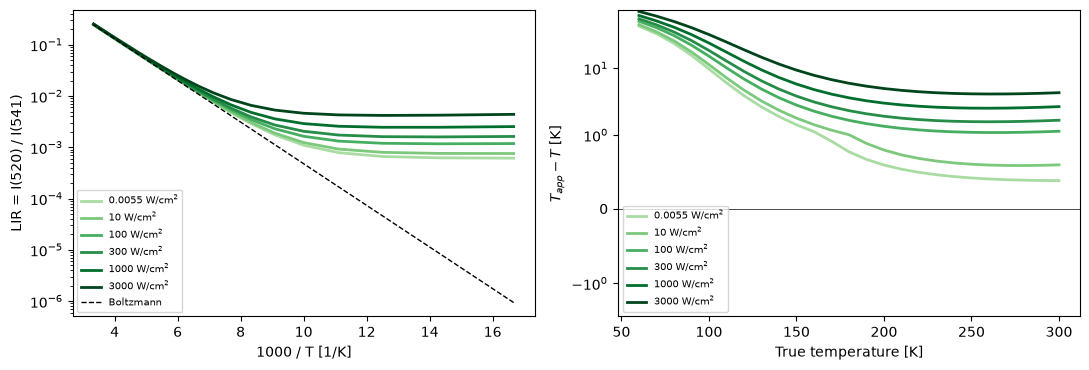

In [8]:
Ts_map = np.arange(60.0, 301.0, 10.0)
P_map = [5.5e-3, 10, 100, 300, 1000, 3000]
T_app = {}
lir_map = {}
for P in P_map:
    ds = steady.sweep(base[(298, "equal")].with_values({M.energy_flux: W(P)}), variable=M.T, values=Ts_map * u.K)
    lir = (ds["line_rad6h1"] / ds["line_rad6s1"]).values
    lir_map[P] = lir
    T_app[P] = gap * hc_k / np.log(C * g_h / g_s / lir)
T_app = pd.DataFrame(T_app, index=pd.Index(Ts_map, name="T [K]"))
bias = T_app.sub(Ts_map, axis=0)
print("Apparent minus true temperature [K] (Boltzmann calibration with the spectroscopic dE and C)")
display(bias.loc[[80, 100, 120, 150, 200, 250, 300]].round(1))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
colors = plt.cm.Greens(np.linspace(0.35, 1, len(P_map)))
for P, col in zip(P_map, colors):
    axs[0].semilogy(1000 / Ts_map, lir_map[P], color=col, lw=2, label=f"{P:g} W/cm$^2$")
    axs[1].plot(Ts_map, bias[P], color=col, lw=2, label=f"{P:g} W/cm$^2$")
axs[0].semilogy(1000 / Ts_map, boltzmann(Ts_map), "k--", lw=1, label="Boltzmann")
axs[0].set_xlabel("1000 / T [1/K]")
axs[0].set_ylabel("LIR = I(520) / I(541)")
axs[0].legend(fontsize=7)
axs[1].axhline(0, color="k", lw=0.5)
axs[1].set_yscale("symlog", linthresh=1)
axs[1].set_xlabel("True temperature [K]")
axs[1].set_ylabel(r"$T_{app} - T$ [K]")
axs[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

The kinetic bias already exists at low power: +9.8 K at 100 K, the intrinsic floor that defines $T_{on}$. Power adds to it:

| True T | 5.5 mW/cm$^2$ | 100 W/cm$^2$ | 300 W/cm$^2$ | 1 kW/cm$^2$ |
|---|---|---|---|---|
| 100 K | +9.8 K | +15.2 K | +18.5 K | +23.9 K |
| 120 K | +3.9 K | +6.9 K | +9.0 K | +12.7 K |
| 150 K | +1.4 K | +2.8 K | +3.8 K | +5.8 K |
| 300 K | +0.4 K | +1.1 K | +1.7 K | +2.7 K |

Above ~200 K the power-induced bias falls to 1–3 K. That is the room-temperature "apparent self-heating" regime reported by Pickel et al. (2018) for single nanoparticles at 10$^3$–10$^5$ W/cm$^2$. Between $T_{on}$ and ~1.5 $T_{on}$, the bias grows quickly with power and is of the same order as typical laser heating.

## 3. Held-out comparisons

These test the *ingredients* of the result. No existing dataset contains $T_{on}(P)$ itself.

### 3.1 Suta 2025

- **$\langle\tau\rangle$ at 77 K.** Suta excites $^2H_{11/2}$ directly at 515 nm and reports the intensity-weighted average decay time of $^4S_{3/2}$, $\langle\tau\rangle = 0.41$ ms. The model reproduces the experiment: no NIR pump, a small initial population in Er6h, and $\langle\tau\rangle = \int t I\,dt/\int I\,dt$ with $I$ = `line_rad6s1`.
- **$T_{on}$ at 5.5 mW/cm$^2$** (consistency only).
- **Radiative rate of $^4S_{3/2}$**: 1.55 ms$^{-1}$ (0.1 % Er), compared with the model's $k_{r6s}$.

In [9]:
rows = []
for (hw, split), s in base.items():
    k77 = k1_direct(s, 77)
    rows.append(
        {
            "hw [cm-1]": hw,
            "CR6 split": split,
            "k_cr6s/k_cr6": 1.0 if split == "equal" else xs[hw],
            "k_cr6h/k_cr6": 1.0 if split == "equal" else (1 - fs0 * xs[hw]) / (1 - fs0),
            "<tau>(77 K) [ms]": 1e3 / k77,
            "T_on(5.5 mW/cm2) [K]": onset(s, suta_P),
        }
    )
suta_table = pd.DataFrame(rows).set_index(["hw [cm-1]", "CR6 split"])
print(f"Suta 2025: <tau>(77 K) = 0.41 ms, T_on = {suta_Ton:.0f} +- {suta_Ton_err:.0f} K;  "
      f"k_r(4S3/2) = {suta_kr / 1e3:.2f} ms-1 vs model k_r6s = {M.k_r6s.default.magnitude / 1e3:.3f} ms-1")
display(suta_table.round(3))

Suta 2025: <tau>(77 K) = 0.41 ms, T_on = 100 +- 5 K;  k_r(4S3/2) = 1.55 ms-1 vs model k_r6s = 1.375 ms-1


k_cr6s/k_cr6  k_cr6h/k_cr6  <tau>(77 K) [ms]  T_on(5.5 mW/cm2) [K]
hw [cm-1] CR6 split                                                                     
298       equal              1.000         1.000             0.323               102.882
          Suta-fixed         0.614         3.905             0.412               100.140
370       equal              1.000         1.000             0.214               107.827
          Suta-fixed         0.319         6.125             0.412               100.200

### 3.2 Xu 2024: 980 nm-excited decays

Xu fits single exponentials to the decays under 980 nm excitation:
- 520 nm: 219 → 157 µs, and 541 nm: 226 → 141 µs, from 353 to 453 K;
- 653 nm: 583 → 497 µs, from 55 to 230 K.

The pulse is not described, so two limits are simulated: a 10 ns pulse of 10 mJ/cm$^2$, and a 1 ms square pulse at Xu's 0.8 W/cm$^2$. The tail is fitted between 50 % and 5 % of the maximum. The pump-free $1/k_1$ is given for reference. Under 980 nm excitation the green tail is set by its feeding from the long-lived Yb $^2F_{5/2}$ / Er $^4I_{11/2}$ reservoir, not by $^4S_{3/2}$.

In [10]:
def tail_metrics(t, y):
    i = np.argmax(y)
    m = (t > t[i]) & (y < 0.5 * y[i]) & (y > 0.05 * y[i])
    return -1e6 / np.polyfit(t[m], np.log(y[m]), 1)[0], t[i] * 1e6


xu_tau = pd.DataFrame(
    {"520 nm": [219, np.nan, 157], "541 nm": [226, np.nan, 141]}, index=pd.Index([353, 403, 453], name="T")
)  # µs, Xu 2024 Fig 5a,b (endpoints in the text)
xu_red = pd.Series([583, np.nan, 497], index=pd.Index([55, 140, 230], name="T"), name="653 nm")  # µs, Fig 5c

save_at = np.linspace(0, 4e-3, 4001) * u.s
pulses = {"10 ns, 10 mJ/cm2": (10e-9, 10e-3 / 10e-9), "1 ms, 0.8 W/cm2": (1e-3, 0.8)}
rows = []
for (hw, split), s in base.items():
    for T in [353, 403, 453]:
        row = {"hw": hw, "split": split, "T": T, "1/k1 pump-free [µs]": 1e6 / k1_direct(s, T)}
        for label, (width, height) in pulses.items():
            res = PulsedExcitation(pulse_width=width * u.s, pulse_height=W(height), pump="energy_flux").solve(
                s.with_values({M.T: T * u.K}), save_at=save_at
            ).pint.dequantify().to_dataframe()
            t = res.index.to_numpy()
            msk = t >= width
            row[f"tail 541, {label} [µs]"] = tail_metrics(t[msk], res["line_rad6s1"].to_numpy()[msk])[0]
        rows.append(row)
xu_model = pd.DataFrame(rows).set_index(["hw", "split", "T"])
display(xu_model.round(0))
display(xu_tau)

1/k1 pump-free [µs]  tail 541, 10 ns, 10 mJ/cm2 [µs]  tail 541, 1 ms, 0.8 W/cm2 [µs]
hw  split      T                                                                                        
298 equal      353                 76.0                            894.0                          1066.0
               403                 51.0                            761.0                           894.0
               453                 33.0                            580.0                           654.0
    Suta-fixed 353                 61.0                            888.0                          1065.0
               403                 34.0                            753.0                           893.0
               453                 19.0                            572.0                           653.0
370 equal      353                 87.0                            932.0                          1108.0
               403                 66.0                            864.0                          1024.0
               453                 49.0                            771.0                           900.0
    Suta-fixed 353                 63.0                            924.0                          1107.0
               403                 38.0                            851.0                          1023.0
               453                 23.0                            757.0                           898.0

,520 nm,541 nm
T,,
353,219.0,226.0
403,NaN,NaN
453,157.0,141.0


In [11]:
ratio_rows = {"Xu 541 nm": xu_tau.loc[353, "541 nm"] / xu_tau.loc[453, "541 nm"],
              "Xu 520 nm": xu_tau.loc[353, "520 nm"] / xu_tau.loc[453, "520 nm"]}
for (hw, split), df in xu_model.groupby(level=[0, 1]):
    df = df.droplevel([0, 1])
    for c in df.columns:
        ratio_rows[f"model hw={hw} {split}: {c}"] = df.loc[353, c] / df.loc[453, c]
display(pd.Series(ratio_rows, name="tau(353 K) / tau(453 K)").round(2).to_frame())

red_rows = []
for (hw, split), s in base.items():
    for T in [55, 140, 230]:
        res = PulsedExcitation(pulse_width=1e-3 * u.s, pulse_height=W(0.8), pump="energy_flux").solve(
            s.with_values({M.T: T * u.K}), save_at=save_at
        ).pint.dequantify().to_dataframe()
        t = res.index.to_numpy()
        msk = t >= 1e-3
        red_rows.append({"hw": hw, "split": split, "T": T,
                         "tail 653, 1 ms 0.8 W/cm2 [µs]": tail_metrics(t[msk], res["line_rad51"].to_numpy()[msk])[0]})
red_model = pd.DataFrame(red_rows).set_index(["hw", "split", "T"])["tail 653, 1 ms 0.8 W/cm2 [µs]"].unstack(level=2)
display(red_model.round(0))
display(xu_red.to_frame().T)

,tau(353 K) / tau(453 K)
Xu 541 nm,1.60
Xu 520 nm,1.39
model hw=298 Suta-fixed: 1/k1 pump-free [µs],3.26
"model hw=298 Suta-fixed: tail 541, 10 ns, 10 mJ/cm2 [µs]",1.55
"model hw=298 Suta-fixed: tail 541, 1 ms, 0.8 W/cm2 [µs]",1.63
model hw=298 equal: 1/k1 pump-free [µs],2.28
"model hw=298 equal: tail 541, 10 ns, 10 mJ/cm2 [µs]",1.54
"model hw=298 equal: tail 541, 1 ms, 0.8 W/cm2 [µs]",1.63
model hw=370 Suta-fixed: 1/k1 pump-free [µs],2.76
"model hw=370 Suta-fixed: tail 541, 10 ns, 10 mJ/cm2 [µs]",1.22


T                 55      140     230
hw  split                            
298 Suta-fixed  950.0  1002.0  1006.0
    equal       923.0   979.0  1000.0
370 Suta-fixed  971.0  1026.0  1014.0
    equal       918.0   981.0  1002.0

T,55,140,230
653 nm,583.0,NaN,497.0


### 3.3 Xu 2024: power-law slopes, and the laser heating they imply

Xu reports $I \propto P^n$ at 303 and 483 K. The power range is not given; it is **assumed** to reach ~1 W/cm$^2$ (the spectra were taken at 0.8 W/cm$^2$), and the model is fitted over 0.05–1 W/cm$^2$.

A thermalized 6s/6h pair forces equal 520 and 541 nm slopes at fixed temperature. Xu's 1.53 vs 1.22 at 303 K can only come from a temperature that changes along the power series:
$$n_{520} - n_{541} = \frac{\Delta E}{kT^2}\frac{dT}{d\ln P}$$
With that heating rate and the model's $\partial \ln I/\partial T$, Xu's slopes are then corrected to isothermal values.

In [12]:
Ps_slope = np.geomspace(0.05, 1.0, 6)
slopes = []
for (hw, split), s in base.items():
    for T in [303, 483]:
        ds = steady.sweep(s.with_values({M.T: T * u.K}), variable=M.energy_flux, values=W(Ps_slope))
        lp = np.log(Ps_slope)
        row = {"hw": hw, "split": split, "T": T}
        for line, nm in [("line_rad6h1", "520"), ("line_rad6s1", "541"), ("line_rad51", "653")]:
            row[nm] = np.polyfit(lp, np.log(ds[line].values), 1)[0]
        slopes.append(row)
slopes = pd.DataFrame(slopes).set_index(["hw", "split", "T"])
xu_slopes = pd.DataFrame({"520": [1.53, 1.82], "541": [1.22, 1.73], "653": [1.30, 1.69]},
                         index=pd.Index([303, 483], name="T"))
print("model, isothermal, 0.05-1 W/cm2 (sigma = 1e-20 cm2)")
display(slopes.round(2))
print("Xu 2024 Fig 3")
display(xu_slopes)

# Laser heating implied by Xu's unequal 520 / 541 slopes in a thermalized pair:
# d ln(I520/I541) / d ln P = (dE / k T^2) dT/d lnP
for T in [303, 483]:
    dn = xu_slopes.loc[T, "520"] - xu_slopes.loc[T, "541"]
    print(f"T = {T} K: n520 - n541 = {dn:.2f}  ->  dT/dlnP = {dn * T**2 / (gap * hc_k):.0f} K per e-fold of power")

model, isothermal, 0.05-1 W/cm2 (sigma = 1e-20 cm2)


520   541   653
hw  split      T                    
298 equal      303  1.89  1.89  2.49
               483  2.01  2.01  2.24
    Suta-fixed 303  1.89  1.89  2.50
               483  2.02  2.02  2.25
370 equal      303  1.89  1.89  2.50
               483  1.95  1.95  2.34
    Suta-fixed 303  1.89  1.89  2.50
               483  1.96  1.96  2.35

Xu 2024 Fig 3


,520,541,653
T,,,
303,1.53,1.22,1.30
483,1.82,1.73,1.69


T = 303 K: n520 - n541 = 0.31  ->  dT/dlnP = 30 K per e-fold of power
T = 483 K: n520 - n541 = 0.09  ->  dT/dlnP = 22 K per e-fold of power


In [13]:
# Heating correction of the slopes: n_measured = n_iso + (d ln I / dT) (dT / d lnP),
# with d ln I / dT from the model at fixed power and dT/dlnP from the 520/541 split above.
dlnI = []
for (hw, split), s in base.items():
    for T in [303, 483]:
        ds = steady.sweep(s.with_values({M.energy_flux: W(0.8)}), variable=M.T, values=[T - 5, T + 5] * u.K)
        row = {"hw": hw, "split": split, "T": T}
        for line, nm in [("line_rad6h1", "520"), ("line_rad6s1", "541"), ("line_rad51", "653")]:
            y = np.log(ds[line].values)
            row[nm] = (y[1] - y[0]) / 10
        dlnI.append(row)
dlnI = pd.DataFrame(dlnI).set_index(["hw", "split", "T"])
heating = pd.Series({T: (xu_slopes.loc[T, "520"] - xu_slopes.loc[T, "541"]) * T**2 / (gap * hc_k) for T in [303, 483]})
corrected = xu_slopes - dlnI.groupby(level=2).mean() * heating.values[:, None]
print("d ln I / dT [1/K] in the model at 0.8 W/cm2")
display(dlnI.round(4))
print("Xu slopes corrected to isothermal with the model's d lnI/dT (mean over the band)")
display(corrected.round(2))

d ln I / dT [1/K] in the model at 0.8 W/cm2


520     541     653
hw  split      T                          
298 equal      303  0.0018 -0.0084  0.0026
               483 -0.0210 -0.0250 -0.0151
    Suta-fixed 303 -0.0018 -0.0120 -0.0009
               483 -0.0238 -0.0278 -0.0178
370 equal      303  0.0041 -0.0060  0.0017
               483 -0.0088 -0.0128 -0.0056
    Suta-fixed 303 -0.0016 -0.0117 -0.0039
               483 -0.0119 -0.0159 -0.0087

Xu slopes corrected to isothermal with the model's d lnI/dT (mean over the band)


,520,541,653
T,,,
303,1.51,1.51,1.30
483,2.19,2.19,1.96


### 3.4 FIR(520/541) above room temperature: Xu 2024 and Yu 2014 Fig 5c

Xu fits FIR = $A e^{-\Delta E/kT} + C$ over 353–453 K and obtains $\Delta E$ = 817 cm$^{-1}$, with 541 nm dropping sharply and 520 nm declining gradually. The same fit is applied to the model at 0.8 W/cm$^2$.

Yu's $R_{HS}$ (Fig 5c, not used for $\eta$) is compared with the model's at 290 W/cm$^2$. The excess is converted into the temperature that the 650 cm$^{-1}$ Boltzmann law would need to explain it.

In [14]:
Ts_fir = np.arange(353, 454, 20.0)
s = base[(298, "equal")]
ds = steady.sweep(s.with_values({M.energy_flux: W(0.8)}), variable=M.T, values=Ts_fir * u.K)
fir = (ds["line_rad6h1"] / ds["line_rad6s1"]).values


def fir_model(T, A, dE, c):
    return A * np.exp(-dE * hc_k / T) + c


popt, _ = curve_fit(fir_model, Ts_fir, fir, p0=(5, 650, 0))
print(f"model FIR 353-453 K at 0.8 W/cm2: A = {popt[0]:.2f}, dE = {popt[1]:.0f} cm-1, offset = {popt[2]:.1e}")
print(f"I541(453)/I541(353) = {ds['line_rad6s1'].values[-1] / ds['line_rad6s1'].values[0]:.2f}, "
      f"I520(453)/I520(353) = {ds['line_rad6h1'].values[-1] / ds['line_rad6h1'].values[0]:.2f}")
# Yu 2014 Fig 5c (R_HS, not used for eta) against the 650 cm-1 Boltzmann law of the model
r = yu["R_HS"][yu.index >= 150]
m = yu_model["2400 (barycenter)"]["R_HS"][yu.index >= 150]
T_eff = 1 / (1 / r.index - np.log(r / m) / (gap * hc_k))
display(pd.DataFrame({"Yu R_HS": r, "model R_HS": m.round(3), "Yu / model": (r / m).round(2),
                      "T that gives Yu's R_HS [K]": np.round(T_eff, 0)}))

model FIR 353-453 K at 0.8 W/cm2: A = 5.53, dE = 650 cm-1, offset = 8.7e-04
I541(453)/I541(353) = 0.20, I520(453)/I520(353) = 0.36


,Yu R_HS,model R_HS,Yu / model,T that gives Yu's R_HS [K]
T,,,,
150,0.02,0.013,1.59,162.0
200,0.12,0.054,2.23,242.0
250,0.23,0.134,1.72,292.0
300,0.30,0.248,1.21,319.0
350,0.58,0.387,1.50,412.0
400,0.80,0.540,1.48,481.0


### 3.5 Summary of the held-out comparisons

| Observable (source) | Data | Model (band) | Deviation | Verdict |
|---|---|---|---|---|
| $k_r(^4S_{3/2})$ (Suta) | 1.55 ms$^{-1}$ | 1.375 ms$^{-1}$ ($k_{r6s}$) | −11 % | agrees |
| $\langle\tau\rangle$(77 K), equal split (Suta) | 0.41 ms | 0.32 ms ($\hbar\omega$ 298) / 0.21 ms (370) | −22 % / −48 % | agrees at 298, not at 370 |
| $T_{on}$ at 5.5 mW/cm$^2$ (Suta) | 100 ± 5 K | 100.1–102.9 K (298), 100.2–107.8 K (370) | ≤ +8 K | consistent (not independent) |
| green decay $\tau(353)/\tau(453)$ under 980 nm (Xu) | 1.60 (541), 1.39 (520) | 1.54–1.63 (298), 1.21–1.23 (370) | ≤ 17 % (298) | agrees at 298 |
| green decay, absolute, 353 K (Xu) | 226 µs | 890–1110 µs | ×4 | **fails** (Yu's bulk: 705 µs at 350 K) |
| red decay $\tau(55)/\tau(230)$ (Xu) | 1.17 | 0.92–0.97 | wrong trend | **fails** |
| slopes, 303 → 483 K (Xu) | 541: 1.22 → 1.73; 653: 1.30 → 1.69 | 541: 1.89 → 1.95–2.02; 653: 2.5 → 2.25–2.35 | red ≈ +1 | **fails** (green direction right; red is 3-photon in Anderson's model) |
| FIR fit 353–453 K (Xu) | $\Delta E$ = 817 cm$^{-1}$ | 650 cm$^{-1}$, offset 9×10$^{-4}$ | — | not reproduced; laser heating likely (3.3) |
| $R_{HS}$ 150–400 K (Yu Fig 5c) | — | model × 1.2–2.2 below | — | consistent with +20–40 K heating |

Two semi-quantitative agreements hold at the preferred $\hbar\omega$ = 298 cm$^{-1}$: Suta's 4S3/2 radiative rate and 77 K decay, and Xu's thermal shortening of the 980 nm-excited green decay. Neither directly tests the low-temperature 6s→9 transfer, which section 5 proposes to measure.

The red channel fails twice (slopes and decay trend). The absolute decay times of Xu's hydrothermal rods are 4× shorter than those of Anderson's and Yu's solid-state material. Both datasets carry clear signatures of laser heating of the order of 10 K or more.

## 4. Mechanism: exact two-level reduction

In the model, Er6s ($^4S_{3/2}$) is populated only from Er6h ($^2H_{11/2}$): the feeding from $^4F_{7/2}$ arrives at Er6h, and the thermal excitation 5→6s is negligible below room temperature. The steady state of Er6s alone then gives, whatever feeds Er6h:
$$k_{21} n_h = (k_{12} + k_1)\, n_s \quad\Rightarrow\quad \text{LIR} = C\frac{n_h}{n_s} = C\left[\frac{g_h}{g_s}e^{-\Delta E/kT} + \frac{k_1}{k_{21}}\right]$$
This uses $k_{12}/k_{21} = (g_h/g_s)(n/(1+n))^p = (g_h/g_s)e^{-\Delta E/kT}$. Here $k_1$ is the $^4S_{3/2}$ decay rate excluding the up-transfer:
$$k_1(T,P) = k_{r6s} + k_{nr6s}F_{3300} + k_{cr6s}\,\rho N_{Er1}F_{1600} + k_{ET6-9}\,\rho\,N_{Yb^*}(T,P)\,F_{2400}, \qquad F_{\Delta}(T) = \left[\frac{1+n(T)}{1+n(T_0)}\right]^{\Delta/\hbar\omega}$$
$T_{on}$ solves $g_h k_{nr}(0)\,n(T_{on})^p = k_1(T_{on}, P)$. In the low-temperature limit, $n^p \approx e^{-\Delta E/kT}$, so
$$T_{on} \approx \frac{\Delta E/k}{\ln\left[g_h k_{nr}(0)/k_1\right]}, \qquad \frac{dT_{on}}{d\ln k_1} \approx \frac{kT_{on}^2}{\Delta E} \approx 11\ \text{K per e-fold of } k_1 \text{ near } 100\ \text{K}$$
The power dependence is therefore logarithmic in $k_1$. Its size is set by the ratio between the ETU term and the intrinsic $k_1 \approx 3\times10^3$ s$^{-1}$, which is where the freeze-out $F_{2400}(110\ \text{K}) \approx 0.12$ enters.

**Relation to "feeding from above".** Pickel et al. (2018) describe the room-temperature effect as population flowing into $^2H_{11/2}$ from higher levels. The reduction shows that, as long as $^4S_{3/2}$ is fed only through $^2H_{11/2}$, the feeding route does not enter the LIR. Only the drain of $^4S_{3/2}$ does: in steady state, the net 6h→6s flux is exactly $k_1 n_s$.

The table checks the reduction channel by channel. Each channel is computed from the steady-state $N_{Er1}$ and $N_{Yb^*}$ of the full model, independently of Er6h and Er6s.

In [15]:
def n_occ(T, hw):
    return 1 / np.expm1(hw * hc_k / T)


def emission_factor(T, hw, mismatch):
    return ((1 + n_occ(T, hw)) / (1 + n_occ(300.0, hw))) ** (mismatch / hw)


def k1_channels(s, P, T, hw=298.0, x=1.0, f69=0):
    """Loss channels of 4S3/2 (s^-1) from the steady populations; exact reduction check."""
    ds = steady.solve(s.with_values({M.energy_flux: W(P), M.T: T * u.K}))
    rho = M.site_density.default.to("1/cm**3").magnitude
    Er1, Yb2 = value(ds, "Er1"), value(ds, "Yb2")
    ch = {
        "radiative": M.k_r6s.default.magnitude,
        "multiphonon 6s->5": M.k_nr6s.default.magnitude * emission_factor(T, hw, 3300),
        "cross relaxation": x * k_cr6 * rho * Er1 * emission_factor(T, hw, 1600),
        "ETU 6s->9": (k69 + f69 * dk69) * rho * Yb2 * emission_factor(T, hw, 2400),
    }
    k_down = g_s * knr0 * (1 + n_occ(T, hw)) ** (gap / hw)
    k_up = g_h * knr0 * n_occ(T, hw) ** (gap / hw)
    lir_reduced = C * (k_up + sum(ch.values())) / k_down
    lir_model = value(ds, "line_rad6h1") / value(ds, "line_rad6s1")
    return ch, lir_model, lir_reduced, Yb2


rows = []
for P in [5.5e-3, 10, 100, 300, 1000]:
    for T in [100.0, 120.0, 300.0]:
        ch, lm, lr, yb2 = k1_channels(base[(298, "equal")], P, T)
        rows.append({"P [W/cm2]": P, "T [K]": T} | ch | {"Yb2 / Yb_total": yb2 / (0.18 * 0.95),
                     "LIR model": lm, "LIR reduced": lr, "rel. diff": lr / lm - 1})
mech = pd.DataFrame(rows).set_index(["P [W/cm2]", "T [K]"])
with pd.option_context("display.float_format", "{:.3g}".format):
    display(mech)

radiative  multiphonon 6s->5  cross relaxation  ETU 6s->9  Yb2 / Yb_total  LIR model  LIR reduced  rel. diff
P [W/cm2] T [K]                                                                                                              
0.0055    100         1375               1.46          1.81e+03      0.731        4.14e-07     0.0011       0.0011  -5.34e-05
          120         1375               1.72          1.96e+03       0.82        4.13e-07    0.00291      0.00291  -9.35e-05
          300         1375                 26          7.32e+03       5.54        3.87e-07      0.245        0.245  -4.98e-05
10        100         1375               1.46           1.8e+03        729        0.000413    0.00124      0.00124  -4.15e-05
          120         1375               1.72          1.94e+03        802        0.000404    0.00305      0.00305  -8.66e-05
          300         1375                 26          7.25e+03   4.97e+03        0.000347      0.246        0.246  -4.97e-05
100       100         1375               1.46          1.73e+03   2.86e+03         0.00162    0.00164      0.00164  -1.83e-05
          120         1375               1.72          1.87e+03   3.12e+03         0.00157    0.00348      0.00348  -7.01e-05
          300         1375                 26          7.05e+03   1.76e+04         0.00123      0.247        0.247  -4.93e-05
300       100         1375               1.46          1.65e+03   5.08e+03         0.00288    0.00206      0.00206   -3.8e-06
          120         1375               1.72          1.79e+03   5.52e+03         0.00278    0.00391      0.00391  -5.68e-05
          300         1375                 26          6.88e+03   2.99e+04         0.00209      0.249        0.249   -4.9e-05
1e+03     100         1375               1.46          1.46e+03   9.61e+03         0.00544     0.0029       0.0029   1.29e-05
          120         1375               1.72          1.59e+03   1.04e+04         0.00525     0.0048       0.0048  -3.72e-05
          300         1375                 26          6.56e+03   5.33e+04         0.00372      0.251        0.251  -4.83e-05

,T_on full model,T_on reduced
P [W/cm2],,
0.0055,102.88,102.88
10.0000,105.26,105.26
100.0000,110.67,110.67
300.0000,115.00,114.99
1000.0000,121.72,121.71


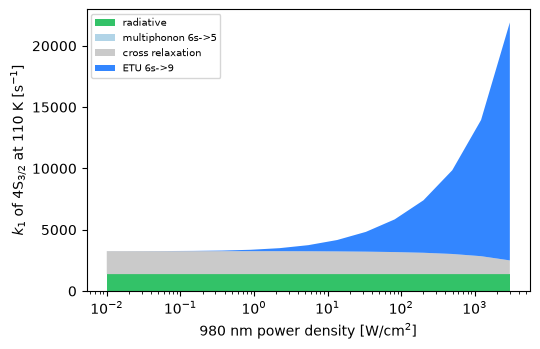

In [16]:
# T_on from the reduced picture: g_h knr0 n(T)^p = k1(T, P) with k1 from the channels above
def onset_reduced(P, s=base[(298, "equal")]):
    def f(T):
        ch, *_ = k1_channels(s, P, T)
        return np.log(g_h * knr0 * n_occ(T, 298.0) ** (gap / 298.0) / sum(ch.values()))
    return brentq(f, 50, 300, xtol=0.05)


Ps_red = [5.5e-3, 10, 100, 300, 1000]
cmp = pd.DataFrame(
    {"T_on full model": band[(298, "equal", 0)].loc[Ps_red].values, "T_on reduced": [onset_reduced(P) for P in Ps_red]},
    index=pd.Index(Ps_red, name="P [W/cm2]"),
)
# closed form: Suta eq. 6 with k1 = k1(T_on, P) of the model
display(cmp.round(2))

P_fine = np.geomspace(1e-2, 3e3, 15)
chs = pd.DataFrame([k1_channels(base[(298, "equal")], P, 110.0)[0] for P in P_fine], index=P_fine)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.stackplot(P_fine, chs.T.values, labels=chs.columns,
             colors=[cmap["g"], "#9ecae1", "#bdbdbd", cmap["b"]], alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"980 nm power density [W/cm$^2$]")
ax.set_ylabel(r"$k_1$ of 4S$_{3/2}$ at 110 K [s$^{-1}$]")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

The reduced LIR matches the full model to ~5×10$^{-5}$, and the reduced $T_{on}$ to 0.01 K. At 100 K and 300 W/cm$^2$, the ETU term (5.1×10$^3$ s$^{-1}$) is 2.6× the intrinsic $k_1$, with only 0.3 % of the Yb$^{3+}$ ions excited. Cross relaxation *decreases* slightly with power because the Er ground state is depleted.

## 5. Proposed experiment

The confound is laser heating. Section 3 shows that the literature data at ≥ 0.8 W/cm$^2$ already carry 10–40 K of laser heating. Heating also raises the LIR, so a single LIR(T) curve at high power cannot separate it from the kinetic effect. On one $\beta$-NaYF$_4$:18Yb,2Er microcrystalline powder in a cryostat (77–200 K):

1. **Pump–probe $k_1$** (decisive, and almost insensitive to heating). Keep a CW 980 nm pump at $P$. Add a weak 515 nm pulse (Suta's Fig 1d setup) and fit the *initial* decay rate (first ~40 µs) of the 540 nm increment. Do not use the intensity-weighted $\langle\tau\rangle$: part of the probe population returns through 6s→9→8→7→6h→6s and adds a slow tail. Two signatures:
   - $k_1$ at 100 K must rise with $P$;
   - the ratio $\Delta k_1(100\ \text{K})/\Delta k_1(300\ \text{K})$ of the pump-induced increments measures the freeze-out of the 6s→9 transfer directly.
2. **LIR(T) at two powers with duty-cycle control.** Use pulses ≥ 5 ms long (Yb $^2F_{5/2}$ lifetime ~1.6 ms), gating detection on the second half of each pulse. At the same peak power, duty cycles of 1 % and 50 % give the same kinetic floor but average heating 50× apart.
3. **Internal reference thermometer.** Record in the same spectra a Stark-sublevel ratio, e.g. 4F9/2 at 653/661 nm (Xu, 55–230 K) or the 4S3/2 → 4I15/2 Stark components. Stark sublevels thermalize much faster than any decay, so they have no kinetic floor and read the true local temperature.

In [17]:
def k1_under_pump(s, P, T, t_end=3e-3, n=30001, delta=1e-7):
    """Pump-probe: CW 980 nm at P to steady state, then a weak 515 nm pulse adds delta to 2H11/2.
    Returns the initial decay rate of the 4S3/2 emission increment (2-40 µs) and 1/<tau>
    (intensity-weighted, which includes the population that returns through 6s->9->8->7->6h)."""
    sp = s.with_values({M.energy_flux: W(P), M.T: T * u.K})
    ss = steady.solve(sp)
    state = {k: value(ss, str(k)) for k in sp.compiled.variables}
    state[M.Er6h] = state[M.Er6h] + delta
    t = np.linspace(0, t_end, n)
    ds = sp.with_values(state).solve(save_at=t * u.s).pint.dequantify()
    I = ds["line_rad6s1"].values - value(ss, "line_rad6s1")
    early = (t > 2e-6) & (t < 40e-6)
    k_init = -np.polyfit(t[early], np.log(I[early]), 1)[0]
    return k_init, np.trapezoid(I, t) / np.trapezoid(t * I, t)


rows = []
for P in [0, 10, 100, 300, 1000]:
    for T in [100.0, 300.0]:
        for name, s in [("barycenter, hw 298", base[(298, "equal")]),
                        ("barycenter, hw 370", base[(370, "equal")]),
                        ("resonant (excluded), hw 298", base[(298, "equal")].with_values(mismatch69(0)))]:
            k_init, k_avg = k1_under_pump(s, P, T)
            rows.append({"P [W/cm2]": P, "T [K]": T, "6s->9": name, "initial rate [1/s]": k_init,
                         "1/<tau> [1/s]": k_avg})
pp = pd.DataFrame(rows).set_index(["6s->9", "T [K]", "P [W/cm2]"]).sort_index()
display(pp.round(0))


for name in ["barycenter, hw 298", "barycenter, hw 370", "resonant (excluded), hw 298"]:
    k = pp.loc[name, "initial rate [1/s]"]
    r = (k.loc[(100.0, 300)] - k.loc[(100.0, 0)]) / (k.loc[(300.0, 300)] - k.loc[(300.0, 0)])
    print(f"{name}: k1(100 K, 300 W/cm2) / k1(100 K, 0) = {k.loc[(100.0, 300)] / k.loc[(100.0, 0)]:.2f};  "
          f"Dk1(100 K) / Dk1(300 K) at 300 W/cm2 = {r:.2f}")

initial rate [1/s]  1/<tau> [1/s]
6s->9                       T [K] P [W/cm2]                                   
barycenter, hw 298          100.0 0                      3188.0         3189.0
                                  10                     3885.0         2456.0
                                  100                    5940.0         3230.0
                                  300                    8105.0         3367.0
                                  1000                  12568.0         2289.0
                            300.0 0                      8867.0         8843.0
                                  10                    12202.0         3465.0
                                  100                   20286.0         5366.0
                                  300                   27379.0         5794.0
                                  1000                  38199.0         3355.0
barycenter, hw 370          100.0 0                      4726.0         4720.0
                                  10                     6313.0         2795.0
                                  100                   10696.0         3594.0
                                  300                   15111.0         3708.0
                                  1000                  23656.0         2497.0
                            300.0 0                      8867.0         8842.0
                                  10                    12203.0         3465.0
                                  100                   20290.0         5366.0
                                  300                   27386.0         5794.0
                                  1000                  38213.0         3354.0
resonant (excluded), hw 298 100.0 0                      3188.0         3190.0
                                  10                     8539.0         5941.0
                                  100                   23631.0         7429.0
                                  300                   40425.0         5001.0
                                  1000                  77688.0         2325.0
                            300.0 0                      8867.0         8843.0
                                  10                    12202.0         3465.0
                                  100                   20286.0         5366.0
                                  300                   27379.0         5794.0
                                  1000                  38199.0         3355.0

barycenter, hw 298: k1(100 K, 300 W/cm2) / k1(100 K, 0) = 2.54;  Dk1(100 K) / Dk1(300 K) at 300 W/cm2 = 0.27
barycenter, hw 370: k1(100 K, 300 W/cm2) / k1(100 K, 0) = 3.20;  Dk1(100 K) / Dk1(300 K) at 300 W/cm2 = 0.56
resonant (excluded), hw 298: k1(100 K, 300 W/cm2) / k1(100 K, 0) = 12.68;  Dk1(100 K) / Dk1(300 K) at 300 W/cm2 = 2.01


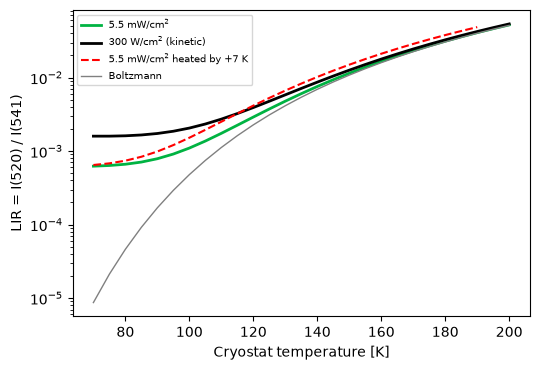

T = 80 K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = 2.44
T = 100 K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = 1.87
T = 120 K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = 1.35
T = 150 K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = 1.10
T = 200 K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = 1.03


In [18]:
# LIR(T) at two powers vs the same low-power curve shifted by laser heating
Ts_exp = np.arange(70.0, 201.0, 5.0)
lo = steady.sweep(base[(298, "equal")].with_values({M.energy_flux: W(suta_P)}), variable=M.T, values=Ts_exp * u.K)
hi = steady.sweep(base[(298, "equal")].with_values({M.energy_flux: W(300)}), variable=M.T, values=Ts_exp * u.K)
lir_lo = (lo["line_rad6h1"] / lo["line_rad6s1"]).values
lir_hi = (hi["line_rad6h1"] / hi["line_rad6s1"]).values
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.semilogy(Ts_exp, lir_lo, color=cmap["g"], lw=2, label="5.5 mW/cm$^2$")
ax.semilogy(Ts_exp, lir_hi, color="black", lw=2, label="300 W/cm$^2$ (kinetic)")
for dTh, ls in [(7, "--")]:
    ax.semilogy(Ts_exp, np.interp(Ts_exp + dTh, Ts_exp, lir_lo, right=np.nan), color=cmap["r"], ls=ls,
                label=f"5.5 mW/cm$^2$ heated by +{dTh} K")
ax.semilogy(Ts_exp, boltzmann(Ts_exp), color="gray", lw=1, label="Boltzmann")
ax.set_xlabel("Cryostat temperature [K]")
ax.set_ylabel("LIR = I(520) / I(541)")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()
ratio = lir_hi / lir_lo
for T in [80, 100, 120, 150, 200]:
    print(f"T = {T} K: LIR(300 W/cm2) / LIR(5.5 mW/cm2) = {ratio[Ts_exp == T][0]:.2f}")

**Quantitative predictions for the experiment** (barycenter mismatch, equal split):
- **Initial decay rate of $^4S_{3/2}$ under the pump, at 100 K:** 3.19 ms$^{-1}$ at $P = 0$, 3.9 at 10 W/cm$^2$, 5.9 at 100, 8.1 at 300 and 12.6 ms$^{-1}$ at 1 kW/cm$^2$ ($\hbar\omega$ = 298). A ×2.5 change at 300 W/cm$^2$ is far above the few-% precision of a decay measurement.
- **Freeze-out ratio:** $\Delta k_1(100\ \text{K})/\Delta k_1(300\ \text{K})$ ≈ 0.27 at 300 W/cm$^2$ for $\hbar\omega$ = 298, and 0.56 for 370 (where $k_1$(100 K) rises ×3.2 instead of ×2.5). A resonant 6s→9 transfer would give ≈ 2.0 (×12.7).
- **LIR at fixed cryostat temperature,** 300 W/cm$^2$ vs 5.5 mW/cm$^2$: ×2.4 at 80 K, ×1.9 at 100 K, ×1.35 at 120 K, ×1.10 at 150 K and ×1.03 at 200 K. The kinetic excess decays as $e^{+\Delta E/kT}$, i.e. it vanishes quickly above $T_{on}$.
- **Heating is different:** it multiplies the LIR by $e^{\Delta E\,\Delta T/kT^2}$, which decays much more slowly. A uniform heating that matched the ×1.9 at 100 K ($\Delta T \approx 7$ K) would still give ×1.3 at 150 K and ×1.2 at 200 K.
- **Falsification:** if $k_1$(100 K) does not rise by at least ~50 % at 300 W/cm$^2$ (or at the power giving the same Yb$^{3+}$ excitation rate $\sigma\Phi \approx 15$ s$^{-1}$), the claim is wrong.

## 6. Draft for the paper

**Abstract-style claim.** The green $^2H_{11/2}/{}^4S_{3/2}$ intensity ratio of Er$^{3+}$ in $\beta$-NaYF$_4$:Yb,Er is the most widely used Boltzmann thermometer. Below a kinetic onset temperature $T_{on} \approx 100$ K it is known to decouple from the lattice temperature (Suta 2025). We show with a rate-equation model that $T_{on}$ is not a material constant. The model contains no parameter adjusted to the onset: Anderson's room-temperature rates, Suta's intrinsic $^2H_{11/2}$–$^4S_{3/2}$ coupling, and the energy-gap law with Suyver's phonon energies.

Under 980 nm excitation, energy-transfer upconversion out of $^4S_{3/2}$ adds a pump-dependent term to the $^4S_{3/2}$ decay rate and raises $T_{on}$:
- by 7–16 K at 100 W/cm$^2$;
- by 11–23 K at 300 W/cm$^2$.

This happens although the transfer is phonon-assisted and freezes out on cooling; the freeze-out is required independently by the rise of the green emission on cooling. An exact two-level reduction, LIR = $C[(g_h/g_s)e^{-\Delta E/kT} + k_1/k_{21}]$, makes the mechanism transparent: only the drain of $^4S_{3/2}$, not its feeding, sets the kinetic floor. Hence the floor can be read out independently by a pump–probe measurement of the $^4S_{3/2}$ decay under CW 980 nm excitation. The model predicts that this rate increases ×2.5–3.2 at 100 K and 300 W/cm$^2$. Ignoring the effect biases Boltzmann thermometry by up to ~9 K at 120 K and ~4 K at 150 K at 300 W/cm$^2$, of the same order as laser heating. We propose a duty-cycle and Stark-reference protocol to separate the two.

**Figures.**
1. Energy-level scheme with the 6s↔6h coupling, the 6s→9 ETU and the reduced two-level picture.
2. $T_{on}$ vs power density, and vs Yb excitation rate, with the sensitivity band; Suta's point; the resonant bound.
3. Constraint on the 6s→9 mismatch from the temperature dependence of the green and $R_{r/g}$ (Yu 2014).
4. Thermometry bias map $T_{app} - T$ vs $T$ and $P$.
5. Decomposition of $k_1$ at 110 K vs power (stacked channels).
6. Proposed experiment: LIR(T) at two powers vs heating; pump–probe $k_1(P)$ at 100 and 300 K for phonon-assisted vs resonant ETU.
7. SI: held-out comparisons (Suta, Xu, Yu Fig 5c) and the reduction to Anderson's model at 300 K.

**Limitations.**
- **No direct test yet.** No existing dataset contains $T_{on}(P)$ or $k_1$ under pump at low temperature. The held-out comparisons test ingredients only: Suta's $k_r$ and 77 K decay, and Xu's thermal shortening of the green decay.
- **The 6s→9 transfer at low $T$ is inferred, not measured.** Its freeze-out is set by a barycenter mismatch and supported by Yu's data, which also calibrated $\eta$. A Stark-resolved mismatch or a Yb-component selectivity of this transfer would change the magnitude.
- **The absolute power axis is uncertain.** It relies on $\sigma = 10^{-20}$ cm$^2$ (literature ~1.2×10$^{-20}$) and on Anderson's fitted transfer rates; scattering in powders changes the in-sample flux. The robust statement is in terms of the Yb$^{3+}$ excitation rate $\sigma\Phi$.
- **$k_{nr}(0)$ comes from Suta's own $T_{on}$** through eq. 6 with $p = 2$. The low-power $T_{on}$ is therefore not an independent check, and the model uses $p = 650/\hbar\omega$ instead of 2.
- **The model fails some held-out observables:** the red power slopes (Anderson's three-photon red), the trend of the red decay with $T$, and the absolute decay times of Xu's hydrothermal rods (×4). The red channel and sample-dependent quenching are not captured. Neither enters the $^4S_{3/2}$ balance directly, but they limit confidence in the model's Yb$^*$ population.
- **The effect competes with laser heating** of comparable size at ≥ 100 W/cm$^2$, and any experiment must separate the two.
- **Novelty.**
  - Suta (2025) and van Swieten et al. (2022) discuss $T_{on}$ as a function of non-radiative coupling, host, concentration and surface quenching, not of excitation power.
  - Anderson (2013) introduced the $^4S_{3/2}$ ETU, but at 300 K only.
  - Pickel et al. (2018) reported a power-dependent ("apparent self-heating") LIR at room temperature in single nanoparticles at 10$^3$–10$^5$ W/cm$^2$, which is the high-temperature, high-power limit of the same physics.
  - We found no prior report of a power-dependent onset temperature at cryogenic temperatures.